In [14]:
%pip install torch torchvision transformers pillow matplotlib

Note: you may need to restart the kernel to use updated packages.


/opt/anaconda3/envs/fashionCLIP-test/lib/python3.12/site-packages/transformers/models/yolos/feature_extraction_yolos.py:38: FutureWarning: The class YolosFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use YolosImageProcessor instead.
  warnings.warn(


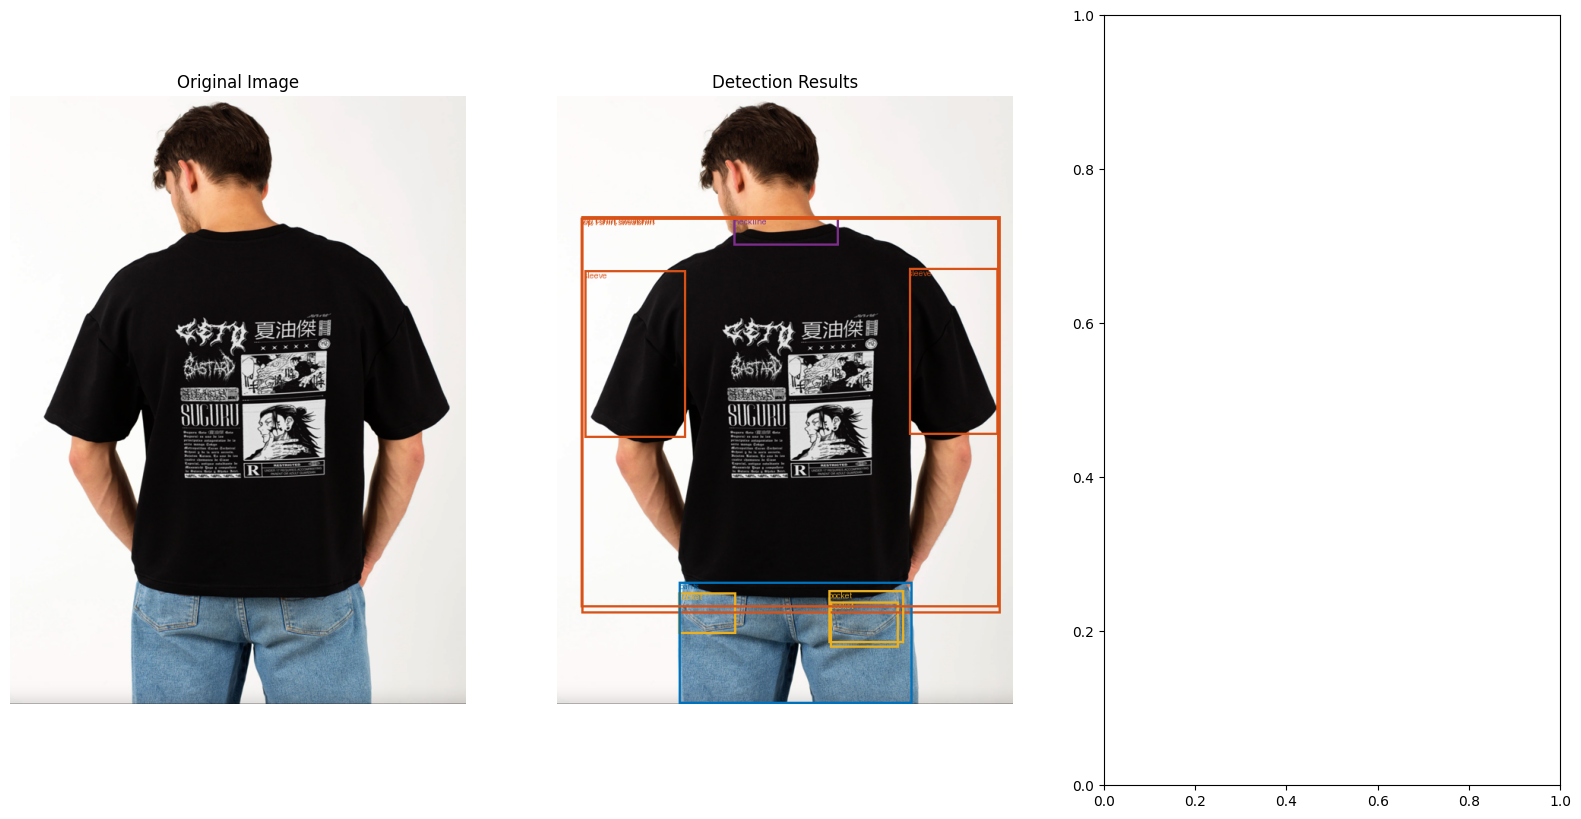

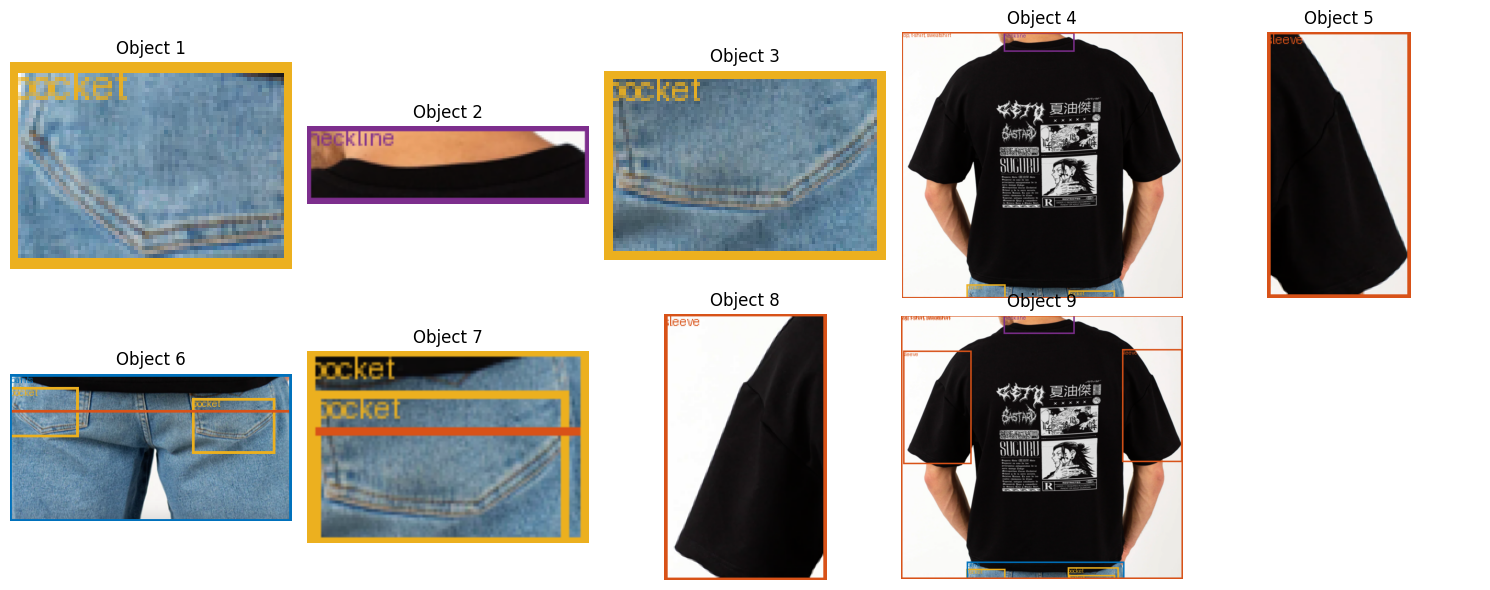

In [1]:
from PIL import Image, ImageDraw
from transformers import YolosFeatureExtractor, YolosForObjectDetection
import torch
import matplotlib.pyplot as plt
from torchvision.transforms import ToTensor, ToPILImage

# Categories for detected objects
cats = ['shirt, blouse', 'top, t-shirt, sweatshirt', 'sweater', 'cardigan', 'jacket', 'vest', 'pants', 'shorts',
        'skirt', 'coat', 'dress', 'jumpsuit', 'cape', 'glasses', 'hat', 'headband, head covering, hair accessory',
        'tie', 'glove', 'watch', 'belt', 'leg warmer', 'tights, stockings', 'sock', 'shoe', 'bag, wallet',
        'scarf', 'umbrella', 'hood', 'collar', 'lapel', 'epaulette', 'sleeve', 'pocket', 'neckline', 'buckle',
        'zipper', 'applique', 'bead', 'bow', 'flower', 'fringe', 'ribbon', 'rivet', 'ruffle', 'sequin', 'tassel']

# Helper functions
def fix_channels(t):
    if len(t.shape) == 2:
        return ToPILImage()(torch.stack([t for i in (0, 0, 0)]))
    if t.shape[0] == 4:
        return ToPILImage()(t[:3])
    if t.shape[0] == 1:
        return ToPILImage()(torch.stack([t[0] for i in (0, 0, 0)]))
    return ToPILImage()(t)

def idx_to_text(i):
    return cats[i]

def box_cxcywh_to_xyxy(x):
    x_c, y_c, w, h = x.unbind(1)
    b = [(x_c - 0.5 * w), (y_c - 0.5 * h),
         (x_c + 0.5 * w), (y_c + 0.5 * h)]
    return torch.stack(b, dim=1)

def rescale_bboxes(out_bbox, size):
    img_w, img_h = size
    b = box_cxcywh_to_xyxy(out_bbox)
    b = b * torch.tensor([img_w, img_h, img_w, img_h], dtype=torch.float32)
    return b

# Random colors for visualization
COLORS = [[0.000, 0.447, 0.741], [0.850, 0.325, 0.098], [0.929, 0.694, 0.125],
          [0.494, 0.184, 0.556], [0.466, 0.674, 0.188], [0.301, 0.745, 0.933]]

# Display results
def display_results(image, outputs, threshold=0.5):
    probas = outputs.logits.softmax(-1)[0, :, :-1]
    keep = probas.max(-1).values > threshold
    bboxes_scaled = rescale_bboxes(outputs.pred_boxes[0, keep].cpu(), image.size)

    # Visualize original image
    plt.figure(figsize=(20, 10))
    plt.subplot(1, 3, 1)
    plt.imshow(image)
    plt.axis("off")
    plt.title("Original Image")

    # Draw bounding boxes and labels
    draw = ImageDraw.Draw(image)
    cropped_images = []
    for prob, (xmin, ymin, xmax, ymax) in zip(probas[keep], bboxes_scaled.tolist()):
        cl = prob.argmax().item()
        label = idx_to_text(cl)
        color = tuple((255 * torch.tensor(COLORS[cl % len(COLORS)])).int().tolist())
        draw.rectangle([xmin, ymin, xmax, ymax], outline=color, width=3)
        draw.text((xmin, ymin), label, fill=color)
        cropped_images.append(image.crop((xmin, ymin, xmax, ymax)))

    # Display annotated image
    plt.subplot(1, 3, 2)
    plt.imshow(image)
    plt.axis("off")
    plt.title("Detection Results")

    # Display cropped detected objects
    num_crops = len(cropped_images)
    if num_crops > 0:
        cols = min(num_crops, 5)
        rows = (num_crops + cols - 1) // cols
        plt.subplot(1, 3, 3)
        fig, axs = plt.subplots(rows, cols, figsize=(15, rows * 3))
        axs = axs.flatten()
        for i, crop in enumerate(cropped_images):
            axs[i].imshow(crop)
            axs[i].axis("off")
            axs[i].set_title(f"Object {i+1}")
        for i in range(num_crops, len(axs)):
            axs[i].axis("off")
    else:
        print("No objects detected above the threshold.")

    plt.tight_layout()
    plt.show()

# Main script
MODEL_NAME = "valentinafeve/yolos-fashionpedia"
IMAGE_PATH = "/Users/Tommy/Downloads/Snipaste_2024-11-07_20-33-13.png"

# Load model and feature extractor
feature_extractor = YolosFeatureExtractor.from_pretrained('hustvl/yolos-small')
model = YolosForObjectDetection.from_pretrained(MODEL_NAME)

# Load and process image
image = Image.open(open(IMAGE_PATH, "rb"))
image = fix_channels(ToTensor()(image))
image = image.resize((600, 800))

# Get model predictions
inputs = feature_extractor(images=image, return_tensors="pt")
outputs = model(**inputs)

# Display results
display_results(image, outputs, threshold=0.5)
